In [1]:
import cv2
import mediapipe as mp
import numpy as np
import os

mp_hands = mp.solutions.hands
hands = mp_hands.Hands(static_image_mode=True, min_detection_confidence=0.5)

DATA_PATH = "C:/Users/Ranuga/Downloads/archive/asl_alphabet_train/asl_alphabet_train"
actions = sorted(os.listdir(DATA_PATH)) 
label_map = {label:num for num, label in enumerate(actions)}

data, labels = [], []

print("Starting landmark extraction...")
for action in actions:
    img_folder = os.path.join(DATA_PATH, action)

    for img_name in os.listdir(img_folder)[:300]: 
        img = cv2.imread(os.path.join(img_folder, img_name))
        if img is None: continue
        
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        results = hands.process(img_rgb)
        
        if results.multi_hand_landmarks:
            for hand_landmarks in results.multi_hand_landmarks:

                res = np.array([[lm.x, lm.y, lm.z] for lm in hand_landmarks.landmark]).flatten()
                data.append(res)
                labels.append(label_map[action])
    print(f"Finished class: {action}")

np.save('X_landmarks.npy', np.array(data))
np.save('y_labels.npy', np.array(labels))
print("Extraction complete. Files saved.")

Starting landmark extraction...
Finished class: A
Finished class: B
Finished class: C
Finished class: D
Finished class: E
Finished class: F
Finished class: G
Finished class: H
Finished class: I
Finished class: J
Finished class: K
Finished class: L
Finished class: M
Finished class: N
Finished class: O
Finished class: P
Finished class: Q
Finished class: R
Finished class: S
Finished class: T
Finished class: U
Finished class: V
Finished class: W
Finished class: X
Finished class: Y
Finished class: Z
Finished class: del
Finished class: nothing
Finished class: space
Extraction complete. Files saved.


In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

X = np.load('X_landmarks.npy')
y = to_categorical(np.load('y_labels.npy')).astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1)

# Simple architecture for 63 input features
model = Sequential([
    Dense(128, activation='relu', input_shape=(63,)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(29, activation='softmax') # 29 ASL classes, since we have 29 classes
])

model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test))

model.save('asl_landmark_model.h5')

C:\Users\Ranuga\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.1004 - loss: 3.2211 - val_accuracy: 0.4688 - val_loss: 2.2770
Epoch 2/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4581 - loss: 2.0410 - val_accuracy: 0.7236 - val_loss: 1.2026
Epoch 3/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6857 - loss: 1.1669 - val_accuracy: 0.8211 - val_loss: 0.7421
Epoch 4/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7958 - loss: 0.7918 - val_accuracy: 0.8916 - val_loss: 0.5179
Epoch 5/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8529 - loss: 0.6029 - val_accuracy: 0.9011 - val_loss: 0.4300
Epoch 6/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8826 - loss: 0.4769 - val_accuracy: 0.9417 - val_loss: 0.3356
Epoch 7/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9005 - loss: 0.4164 - val_accuracy: 0.9390 - val_loss: 0.2898
Epoch 8/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9092 - loss: 0.3644 - val_accu

Detected 28 classes in test data.

Classification Report:
              precision    recall  f1-score   support

           A       1.00      1.00      1.00        37
           B       1.00      1.00      1.00        24
           C       1.00      1.00      1.00        25
           D       1.00      1.00      1.00        29
           E       1.00      1.00      1.00        27
           F       1.00      1.00      1.00        33
           G       1.00      1.00      1.00        30
           H       1.00      0.96      0.98        27
           I       1.00      1.00      1.00        27
           J       0.96      1.00      0.98        26
           K       1.00      1.00      1.00        40
           L       1.00      1.00      1.00        22
           M       1.00      0.87      0.93        15
           N       0.67      1.00      0.80         4
           O       1.00      1.00      1.00        21
           P       1.00      1.00      1.00        32
           Q       1.00

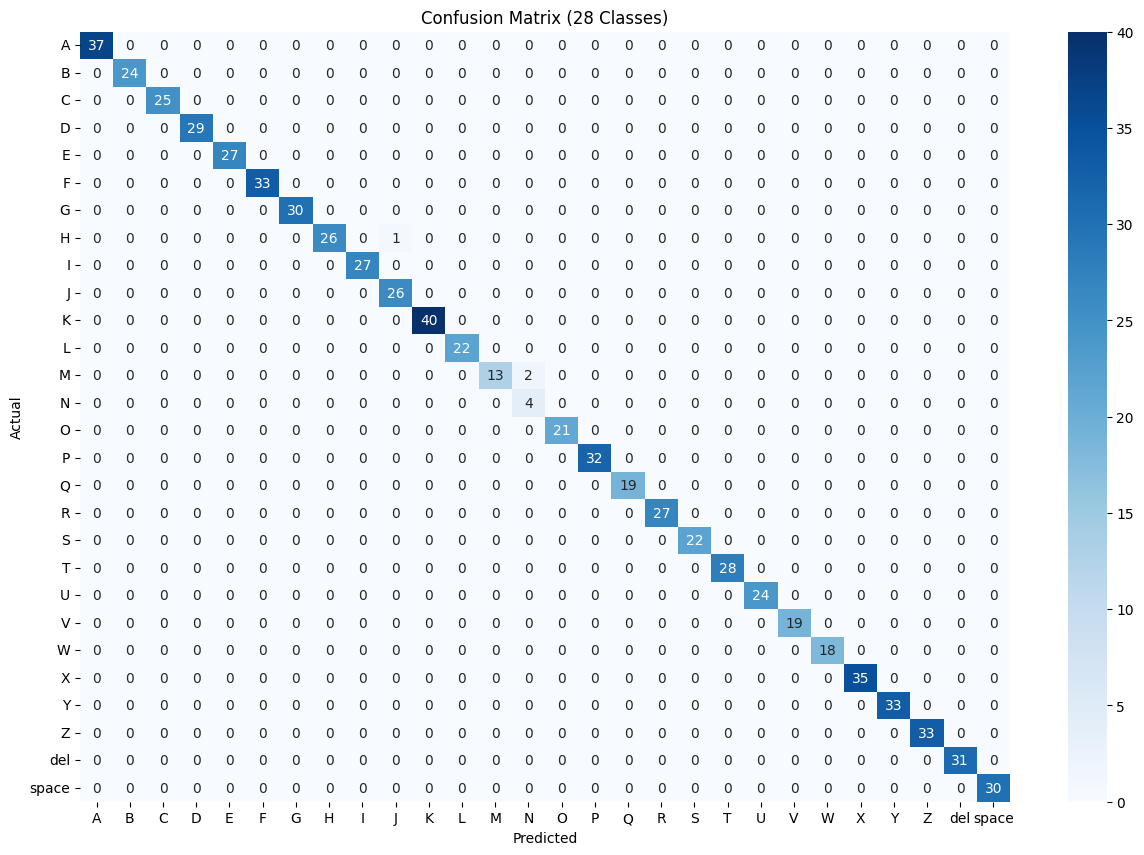

In [27]:
from sklearn.metrics import classification_report, confusion_matrix

unique_classes = np.unique(y_test)
num_classes_found = len(unique_classes)

present_actions = [actions[i] for i in unique_classes]

print(f"Detected {num_classes_found} classes in test data.")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=present_actions))

plt.figure(figsize=(15, 10))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', 
            cmap='Blues', xticklabels=present_actions, yticklabels=present_actions)
plt.title(f"Confusion Matrix ({num_classes_found} Classes)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [37]:
import cv2
import mediapipe as mp
import numpy as np
import os

mp_hands = mp.solutions.hands
hands = mp_hands.Hands(static_image_mode=True, min_detection_confidence=0.5)

DATA_PATH = "C:/Users/Ranuga/Downloads/archive/asl_alphabet_train/asl_alphabet_train"
actions = sorted(os.listdir(DATA_PATH)) 

raw_images = []

print("Extracting images to match landmarks...")
for action in actions:
    img_folder = os.path.join(DATA_PATH, action)
    # Use the same limit (:300) used in your original script
    for img_name in os.listdir(img_folder)[:300]: 
        img = cv2.imread(os.path.join(img_folder, img_name))
        if img is None: continue
        
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        results = hands.process(img_rgb)
        
        # IMPORTANT: Only save the image if a hand was detected
        # This ensures the 1st image here matches the 1st landmark in your .npy file
        if results.multi_hand_landmarks:
            for _ in results.multi_hand_landmarks:
                # Resize to save space, but keep it as uint8 for OpenCV
                raw_images.append(cv2.resize(img, (200, 200))) 
    print(f"Syncing images for class: {action}")

np.save('raw_images.npy', np.array(raw_images))
print("Successfully created raw_images.npy. You can now use your existing model.")

Extracting images to match landmarks...
Syncing images for class: A
Syncing images for class: B
Syncing images for class: C
Syncing images for class: D
Syncing images for class: E
Syncing images for class: F
Syncing images for class: G
Syncing images for class: H
Syncing images for class: I
Syncing images for class: J
Syncing images for class: K
Syncing images for class: L
Syncing images for class: M
Syncing images for class: N
Syncing images for class: O
Syncing images for class: P
Syncing images for class: Q
Syncing images for class: R
Syncing images for class: S
Syncing images for class: T
Syncing images for class: U
Syncing images for class: V
Syncing images for class: W
Syncing images for class: X
Syncing images for class: Y
Syncing images for class: Z
Syncing images for class: del
Syncing images for class: nothing
Syncing images for class: space
Successfully created raw_images.npy. You can now use your existing model.


24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


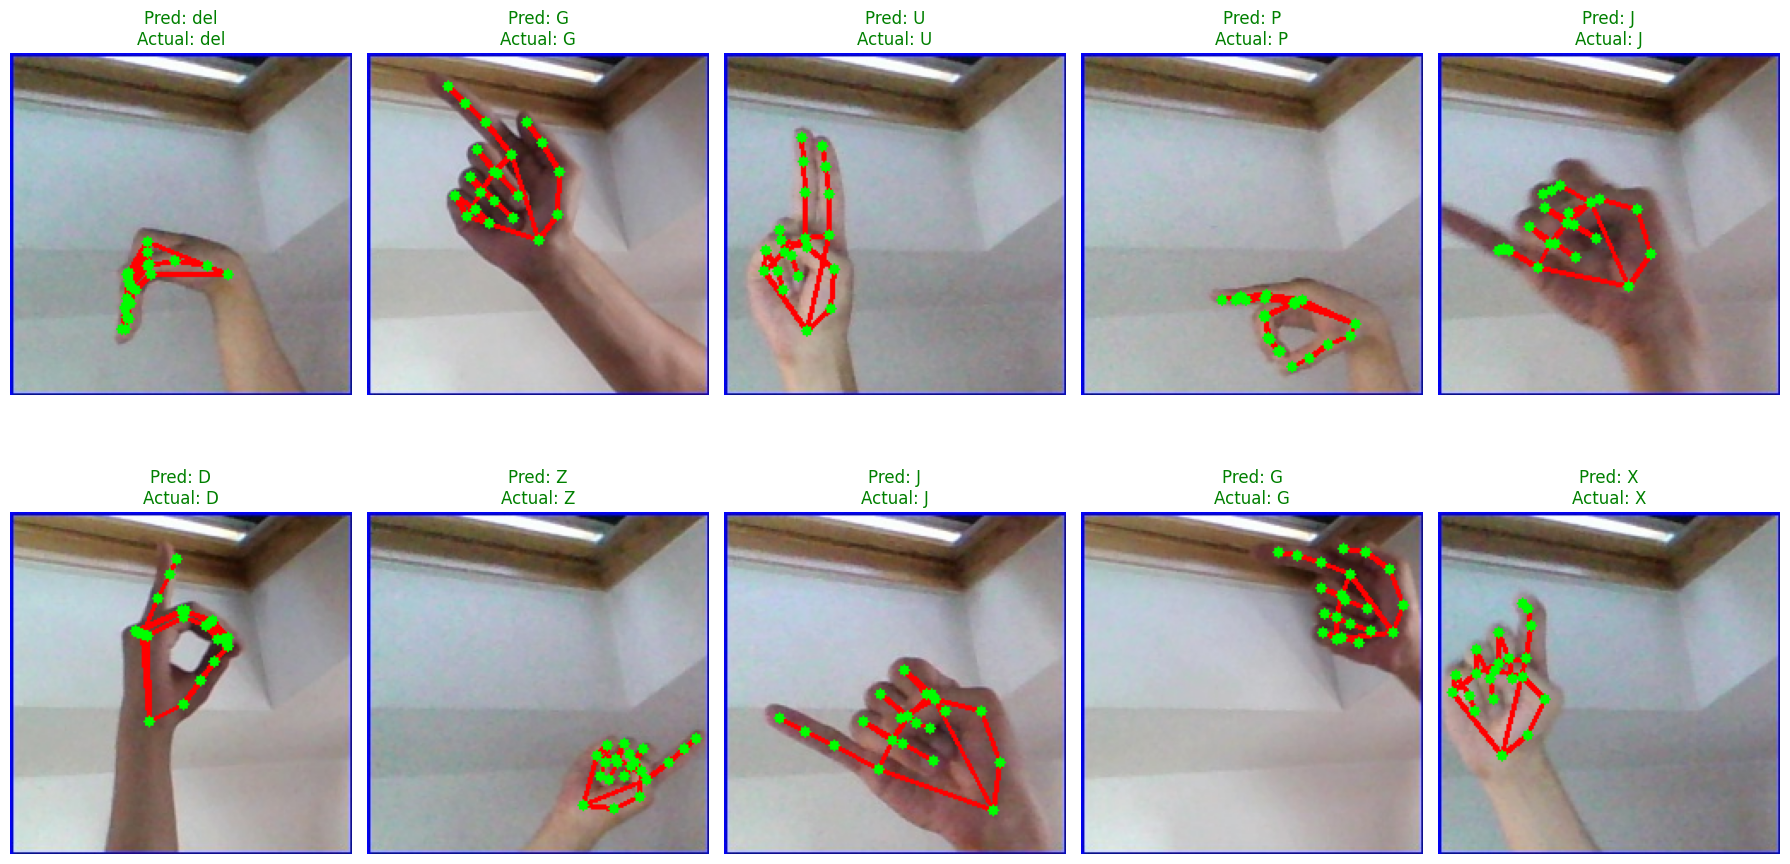

In [42]:
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

import os
import logging
# Completely silence TensorFlow logging
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
logging.getLogger('tensorflow').setLevel(logging.ERROR)


# Load everything
X = np.load('X_landmarks.npy')
y = np.load('y_labels.npy')
images = np.load('raw_images.npy')
model = load_model('asl_landmark_model.h5', compile=False)

# Split using the SAME random_state as your training script
from sklearn.model_selection import train_test_split
_, X_test, _, y_test, _, x_test_imgs = train_test_split(
    X, y, images, test_size=0.1, random_state=42
)

y_pred = np.argmax(model.predict(X_test), axis=1)
mp_hands = mp.solutions.hands

plt.figure(figsize=(18, 10))
for i in range(10):
    plt.subplot(2, 5, i+1)
    img = cv2.cvtColor(x_test_imgs[i].astype(np.uint8), cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape
    res = X_test[i].reshape(21, 3)

    # Draw Connections (Skeleton)
    for connection in mp_hands.HAND_CONNECTIONS:
        p1 = (int(res[connection[0]][0] * w), int(res[connection[0]][1] * h))
        p2 = (int(res[connection[1]][0] * w), int(res[connection[1]][1] * h))
        cv2.line(img, p1, p2, (255, 0, 0), 2)

    # Draw Points
    for lm in res:
        cv2.circle(img, (int(lm[0]*w), int(lm[1]*h)), 3, (0, 255, 0), -1)

    color = 'green' if y_pred[i] == y_test[i] else 'red'
    plt.imshow(img)
    plt.title(f"Pred: {actions[y_pred[i]]}\nActual: {actions[y_test[i]]}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [3]:
from tensorflow.keras.models import load_model

In [1]:
import cv2
import mediapipe as mp
import numpy as np
from tensorflow.keras.models import load_model

# 1. INITIALIZE MEDIAPIPE AND LOAD MODEL
mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils
hands = mp_hands.Hands(
    static_image_mode=False, 
    max_num_hands=1, 
    min_detection_confidence=0.7, 
    min_tracking_confidence=0.5
)

# Replace with your actual labels list from your training script
# Ensure this matches the order of folders in your dataset
actions = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 
           'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 
           'del', 'nothing', 'space']

model = load_model('asl_landmark_model.h5')

# 2. START VIDEO CAPTURE
cap = cv2.VideoCapture(0)

print("Starting Real-Time Tracking...")
print("Ensure your hand is visible to the camera.")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Flip the frame for a mirror effect
    frame = cv2.flip(frame, 1)
    
    # MediaPipe requires RGB images
    img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = hands.process(img_rgb)

    # 3. IF HAND LANDMARKS ARE DETECTED
    if results.multi_hand_landmarks:
        for hand_landmarks in results.multi_hand_landmarks:
            # Draw the skeleton (the green points and red lines you wanted)
            mp_drawing.draw_landmarks(
                frame, 
                hand_landmarks, 
                mp_hands.HAND_CONNECTIONS,
                mp_drawing.DrawingSpec(color=(0, 255, 0), thickness=2, circle_radius=4), # Points
                mp_drawing.DrawingSpec(color=(0, 0, 255), thickness=2) # Connections
            )

            # 4. PREPROCESS LANDMARKS FOR PREDICTION
            # Convert the 21 landmarks into a flat array of 63 features
            landmark_list = []
            for lm in hand_landmarks.landmark:
                landmark_list.extend([lm.x, lm.y, lm.z])
            
            # Reshape to (1, 63) to match model input
            input_data = np.array(landmark_list).reshape(1, 63)

            # 5. MODEL PREDICTION
            prediction = model.predict(input_data, verbose=0)
            pred_idx = np.argmax(prediction)
            confidence = np.max(prediction)
            
            # 6. DISPLAY RESULT
            label = actions[pred_idx]
            display_text = f"{label} ({confidence*100:.1f}%)"
            
            # Draw label above the hand
            cv2.putText(frame, display_text, (50, 50), 
                        cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA)

    # Show the final window
    cv2.imshow('MediaPipe ASL Recognition', frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

Starting Real-Time Tracking...
Ensure your hand is visible to the camera.
